In [ ]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import re
import unicodedata

## 1. Data Exploration

In [58]:
ds = load_dataset("pythainlp/wisesight_sentiment")

In [59]:
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df["dataset_type"] = "train"
val_df["dataset_type"] = "validation"
test_df["dataset_type"] = "test"

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

df.head(5)

,texts,category,dataset_type
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train
3,สนใจ new mazda2ครับ,1,train
4,😍😍,0,train


In [60]:
output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(
    output_dir / "data.csv",
    index=False
)

## 2. Data Preprocessing

In [61]:
display(df.isna().sum())

texts           0
category        0
dataset_type    0
dtype: int64

In [62]:
label_count = (
    df.groupby("texts")["category"].transform("nunique")
)

conflict_rows = df[
    label_count > 1
].copy()

display(
    conflict_rows.sort_values(
        ["texts", "dataset_type", "category"]
    )
)

,texts,category,dataset_type
9278,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,0,train
4977,toyota ผมแนะนำถ้าใครซื้ออย่าเอารถค้างสต็อคตามป...,2,train
13250,ชุมพรมั้ยอ้ะ?!😂,0,train
7008,ชุมพรมั้ยอ้ะ?!😂,3,train
15561,ซีวิค มีส่วนลดเท่าไหร่ครับ,0,train
13932,ซีวิค มีส่วนลดเท่าไหร่ครับ,3,train
26163,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,1,test
3214,นกแอร์กับแอร์เอเชียเที่ยวบินไประนองยกเลิกมั้ยค่ะ,3,train
19476,น้องอยากกิน,1,train
23817,น้องอยากกิน,0,validation


In [63]:
df_clean = df[
    label_count == 1
].copy()

In [64]:
#clean text
def clean_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", "USER", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_clean["texts_clean"] = df_clean["texts"].apply(clean_text)

In [65]:
#sentiment name
LABEL_NAMES = {
    0: "positive",
    1: "neutral",
    2: "negative",
    3: "question"
}

df_clean["sentiment"] = df_clean["category"].map(LABEL_NAMES)
df_clean.head(5)

,texts,category,dataset_type,texts_clean,sentiment
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,train,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,neutral
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,train,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,neutral
2,บัตรสมาชิกลดได้อีกไหมคับ,1,train,บัตรสมาชิกลดได้อีกไหมคับ,neutral
3,สนใจ new mazda2ครับ,1,train,สนใจ new mazda2ครับ,neutral
4,😍😍,0,train,😍😍,positive


In [ ]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(
    output_dir / "data.csv",
    index=False
)

## 3. Model Training

In [71]:
random_state = 42
test_size = 0.2

In [72]:
X_train = df_clean[df_clean["dataset_type"] == "train"]["texts_clean"]
y_train = df_clean[df_clean["dataset_type"] == "train"]["category"]

X_val = df_clean[df_clean["dataset_type"] == "validation"]["texts_clean"]
y_val = df_clean[df_clean["dataset_type"] == "validation"]["category"]

In [75]:
print("Train dataset shape:", X_train.shape[0])
print("Validation dataset shape:", X_val.shape[0])

Train dataset shape: 21589
Validation dataset shape: 2400


In [76]:
#Model

model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 5), max_features=100_000, sublinear_tf=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state))
])


In [77]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 4. Model Evaluation

In [78]:
y_pred = model.predict(X_val)

print(
    classification_report(
        y_val,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=["positive", "neutral", "negative", "question"]
    )
)

              precision    recall  f1-score   support

    positive       0.49      0.57      0.53       432
     neutral       0.79      0.66      0.72      1290
    negative       0.69      0.80      0.74       637
    question       0.23      0.56      0.33        41

    accuracy                           0.68      2400
   macro avg       0.55      0.65      0.58      2400
weighted avg       0.70      0.68      0.68      2400



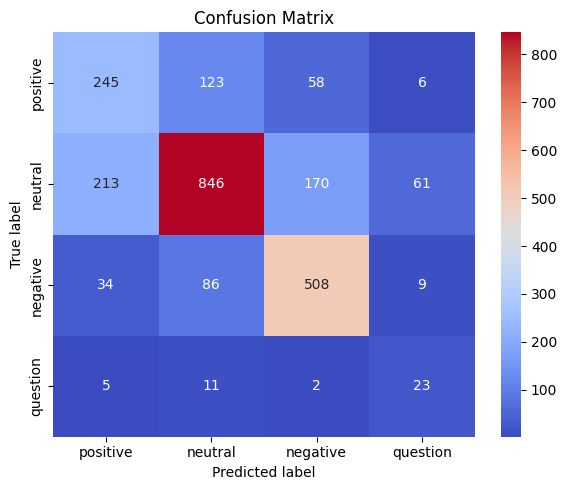

In [79]:
cm = confusion_matrix(y_val, y_pred, labels=[0,1,2,3])

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["positive", "neutral", "negative", "question"], yticklabels=["positive", "neutral", "negative", "question"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()